# ⚡ EV Battery Intelligence Platform
## Li-Ion Battery Status Classification & Diagnostic Analysis
### Data Science Team | ElectricVolt Battery Manufacturing Co.

---

> *"Empowering intelligent battery management through data-driven diagnostics"*

---

## 📋 Problem Statement

### Background

As a leading Electric Vehicle (EV) Battery Manufacturing company, maintaining the **health, performance, and longevity** of Lithium-Ion (Li-Ion) batteries is mission-critical — both for customer safety and for the company's operational reputation. Batteries in the field continuously emit sensor data capturing their electrical characteristics, but without automated intelligence, field engineers are left to manually inspect these readings, which is:

- **Slow** — thousands of batteries produce millions of data points daily
- **Inconsistent** — human interpretation varies across technicians
- **Reactive** — problems are often caught after damage has occurred

### The Challenge

We have a dataset of **452 battery sensor readings**, each described by six electrical attributes:

| Feature | Description |
|---|---|
| `Voltage` | Instantaneous terminal voltage |
| `Current` | Instantaneous current draw |
| `Temperature` | Battery cell temperature |
| `AverageVoltage` | Rolling average voltage |
| `AverageCurrent` | Rolling average current |
| `SOC` | State of Charge (0–1 normalized) |

Each reading is labeled with one of three **Battery Status** categories:
- 🔴 **Needs Charging** — Battery is critically low and must be charged
- 🟡 **Partially Charged** — Battery has moderate charge; monitor closely
- 🟢 **Fully Charged** — Battery is at optimal charge; ready for operation

### Our Objective

Build an **intelligent classification system** that:
1. Automatically categorizes battery status from sensor readings
2. Identifies the most critical electrical indicators for battery health
3. Provides actionable insights to operations and engineering teams
4. Enables **proactive maintenance** rather than reactive failure response

---

## 1. Environment Setup & Library Imports

In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# ── Core Data Libraries ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_auc_score, ConfusionMatrixDisplay
)

# ── Algorithms ────────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# ── Styling ───────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Brand palette
PALETTE = {
    'Needs Charging':    '#E74C3C',   # red
    'Partially Charged': '#F39C12',   # amber
    'Fully Charged':     '#27AE60',   # green
}
COLOR_LIST = list(PALETTE.values())

print('✅ All libraries imported successfully!')
print(f'   NumPy  : {np.__version__}')
print(f'   Pandas : {pd.__version__}')
import sklearn; print(f'   Sklearn: {sklearn.__version__}')

✅ All libraries imported successfully!
   NumPy  : 2.4.2
   Pandas : 3.0.1
   Sklearn: 1.8.0


---
## 2. Data Loading & Initial Inspection

In [4]:
# Load dataset
df = pd.read_excel('Automotive_Data.xlsx')

print('═' * 55)
print('        EV BATTERY SENSOR DATASET — OVERVIEW')
print('═' * 55)
print(f'  Rows (readings)  : {df.shape[0]}')
print(f'  Columns (features): {df.shape[1]}')
print(f'  Missing values   : {df.isnull().sum().sum()}')
print(f'  Duplicate rows   : {df.duplicated().sum()}')
print('═' * 55)
df.head(10)

═══════════════════════════════════════════════════════
        EV BATTERY SENSOR DATASET — OVERVIEW
═══════════════════════════════════════════════════════
  Rows (readings)  : 452
  Columns (features): 7
  Missing values   : 0
  Duplicate rows   : 0
═══════════════════════════════════════════════════════


,Voltage,Current,Temperature,AverageVoltage,AverageCurrent,SOC,Battery Status
0,0.385148,0.75102,0.303101,0.385148,0.75102,0.206417,Needs Charging
1,0.385460,0.75102,0.456070,0.385304,0.75102,0.206417,Needs Charging
2,0.385496,0.75102,0.622089,0.385368,0.75102,0.206417,Fully Charged
3,0.385647,0.75102,0.770260,0.385438,0.75102,0.206417,Needs Charging
4,0.386431,0.75102,0.846668,0.385636,0.75102,0.206417,Needs Charging
5,0.387775,0.75102,0.857070,0.385993,0.75102,0.206417,Needs Charging
6,0.389148,0.75102,0.854742,0.386660,0.75102,0.206417,Fully Charged
7,0.390238,0.75102,0.876458,0.387456,0.75102,0.206417,Needs Charging
8,0.391170,0.75102,0.900069,0.388402,0.75102,0.206417,Needs Charging
9,0.391969,0.75102,0.906513,0.389455,0.75102,0.206417,Fully Charged


In [5]:
# Data types & memory
print('Column Types & Memory Usage:')
print('-' * 40)
df.info()

Column Types & Memory Usage:
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Voltage         452 non-null    float64
 1   Current         452 non-null    float64
 2   Temperature     452 non-null    float64
 3   AverageVoltage  452 non-null    float64
 4   AverageCurrent  452 non-null    float64
 5   SOC             452 non-null    float64
 6   Battery Status  452 non-null    str    
dtypes: float64(6), str(1)
memory usage: 24.8 KB


In [6]:
# Statistical summary
print('Statistical Summary — Numerical Features:')
df.describe().round(4)

Statistical Summary — Numerical Features:


,Voltage,Current,Temperature,AverageVoltage,AverageCurrent,SOC
count,452.0000,452.0000,452.0000,452.0000,452.0000,452.0000
mean,0.7054,0.7588,0.6442,0.7021,0.7588,0.6303
std,0.2504,0.0679,0.3119,0.2481,0.0595,0.3303
min,0.1789,0.5134,0.2578,0.3121,0.6084,0.2064
25%,0.4169,0.7510,0.2831,0.4165,0.7491,0.2167
50%,0.7292,0.7510,0.9036,0.7247,0.7510,0.6607
75%,0.9708,0.7712,0.9226,0.9704,0.7664,0.9914
max,0.9776,0.8756,0.9537,0.9775,0.8755,1.0000


In [7]:
# Class distribution
status_counts = df['Battery Status'].value_counts()
status_pct    = df['Battery Status'].value_counts(normalize=True) * 100

print('Battery Status Distribution:')
print('-' * 45)
for label in status_counts.index:
    bar = '█' * int(status_pct[label] / 2)
    print(f'  {label:<20} {status_counts[label]:>4}  ({status_pct[label]:.1f}%)  {bar}')

Battery Status Distribution:
---------------------------------------------
  Fully Charged         194  (42.9%)  █████████████████████
  Partially Charged     137  (30.3%)  ███████████████
  Needs Charging        121  (26.8%)  █████████████


---
## 3. Exploratory Data Analysis (EDA)
### 3.1 Class Distribution

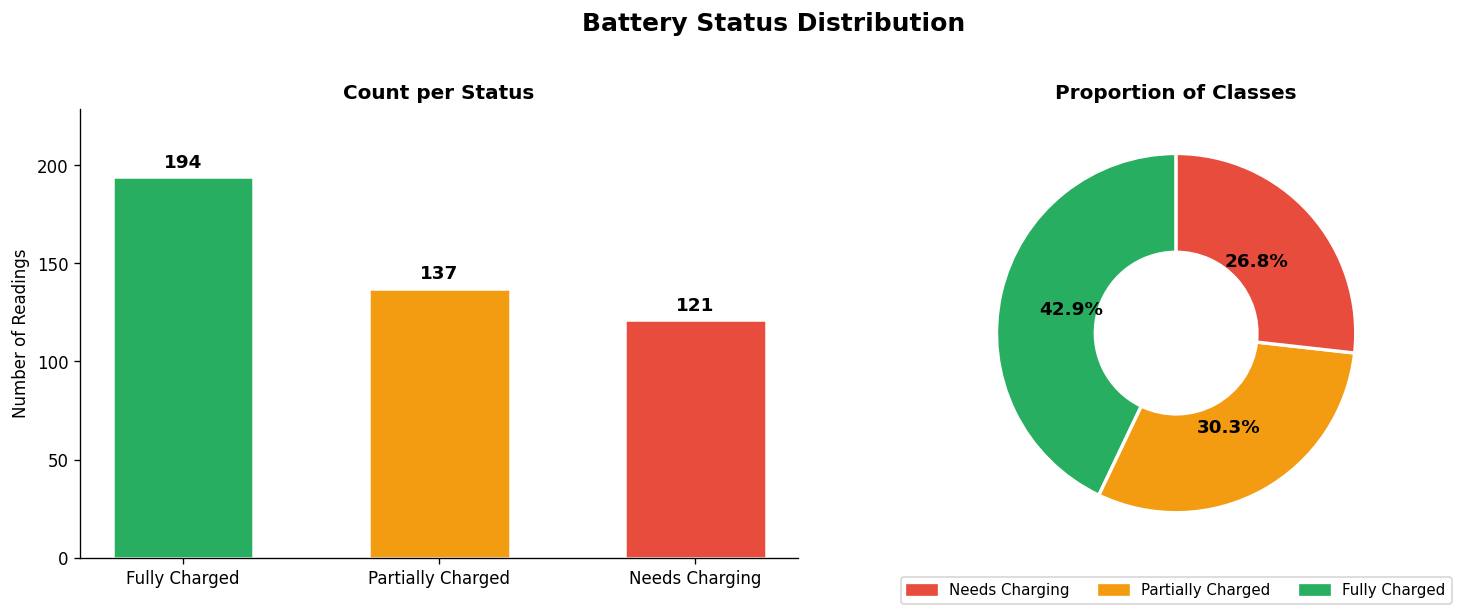


📊 Insight: The dataset is moderately imbalanced. Fully Charged leads at 42.9%,
   while Needs Charging is the smallest class at 26.8%. We will account for this in modelling.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Battery Status Distribution', fontsize=15, fontweight='bold', y=1.02)

labels  = status_counts.index.tolist()
colors  = [PALETTE[l] for l in labels]
counts  = status_counts.values

# Bar chart
bars = axes[0].bar(labels, counts, color=colors, edgecolor='white', linewidth=1.5, width=0.55)
axes[0].set_title('Count per Status', fontweight='bold')
axes[0].set_ylabel('Number of Readings')
axes[0].set_ylim(0, max(counts) * 1.18)
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(cnt), ha='center', va='bottom', fontweight='bold', fontsize=11)

# Donut chart
wedges, texts, autotexts = axes[1].pie(
    counts, labels=None, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    textprops=dict(fontsize=11)
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Proportion of Classes', fontweight='bold')
axes[1].legend(labels, loc='lower center', bbox_to_anchor=(0.5, -0.12),
               ncol=3, fontsize=9,
               handles=[mpatches.Patch(color=c, label=l) for l, c in PALETTE.items()])

plt.tight_layout()
plt.savefig('plot_01_class_distribution.png', bbox_inches='tight')
plt.show()
print('\n📊 Insight: The dataset is moderately imbalanced. Fully Charged leads at 42.9%,')
print('   while Needs Charging is the smallest class at 26.8%. We will account for this in modelling.')

### 3.2 Feature Distributions by Battery Status

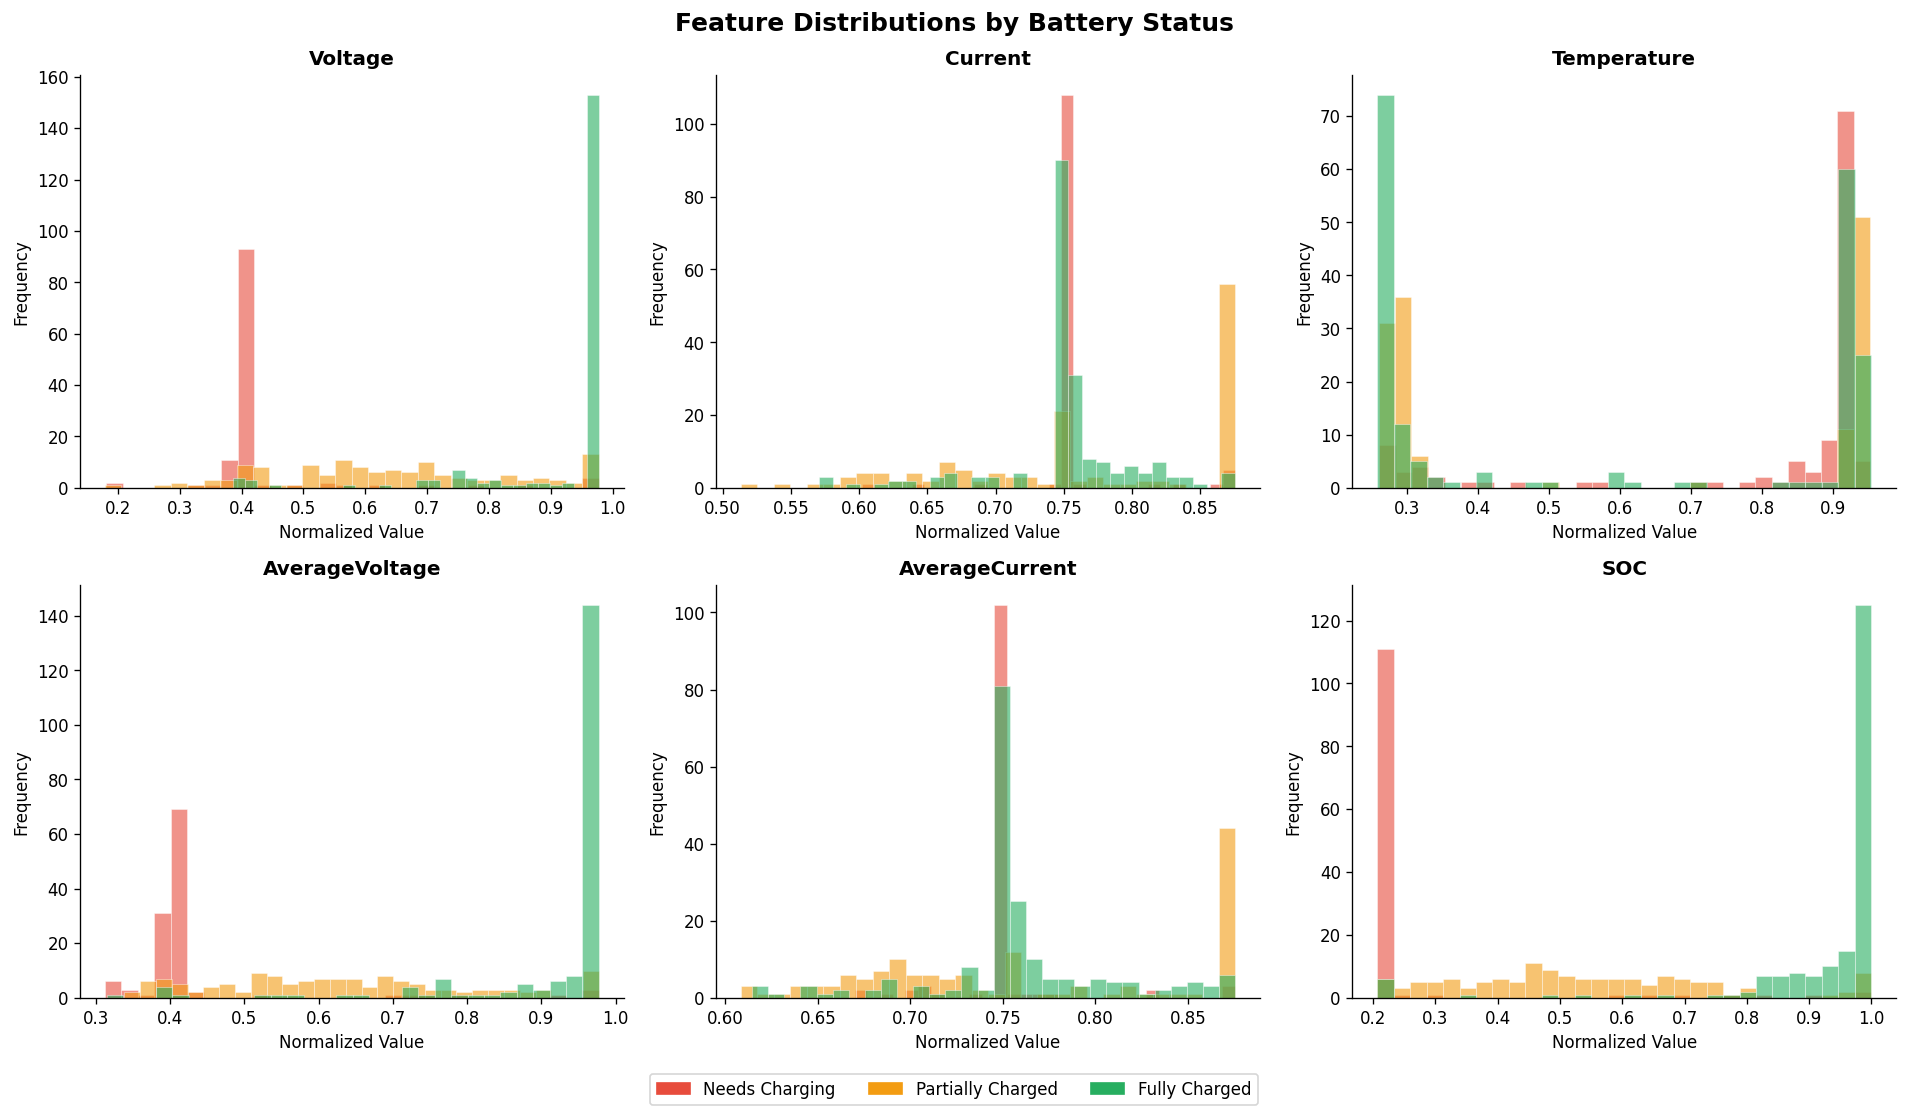


📊 Insight: SOC and Voltage show clear separation across status classes,
   making them strong predictors. Current and AverageCurrent are more overlapping.


In [9]:
features = ['Voltage', 'Current', 'Temperature', 'AverageVoltage', 'AverageCurrent', 'SOC']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Feature Distributions by Battery Status', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(features):
    for status, color in PALETTE.items():
        subset = df[df['Battery Status'] == status][feat]
        axes[i].hist(subset, bins=30, alpha=0.6, color=color, label=status, edgecolor='white', linewidth=0.4)
    axes[i].set_title(feat, fontweight='bold', fontsize=12)
    axes[i].set_xlabel('Normalized Value')
    axes[i].set_ylabel('Frequency')

handles = [mpatches.Patch(color=c, label=l) for l, c in PALETTE.items()]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.04), frameon=True)

plt.tight_layout()
plt.savefig('plot_02_feature_distributions.png', bbox_inches='tight')
plt.show()
print('\n📊 Insight: SOC and Voltage show clear separation across status classes,')
print('   making them strong predictors. Current and AverageCurrent are more overlapping.')

### 3.3 Box Plots — Spread & Outliers per Feature

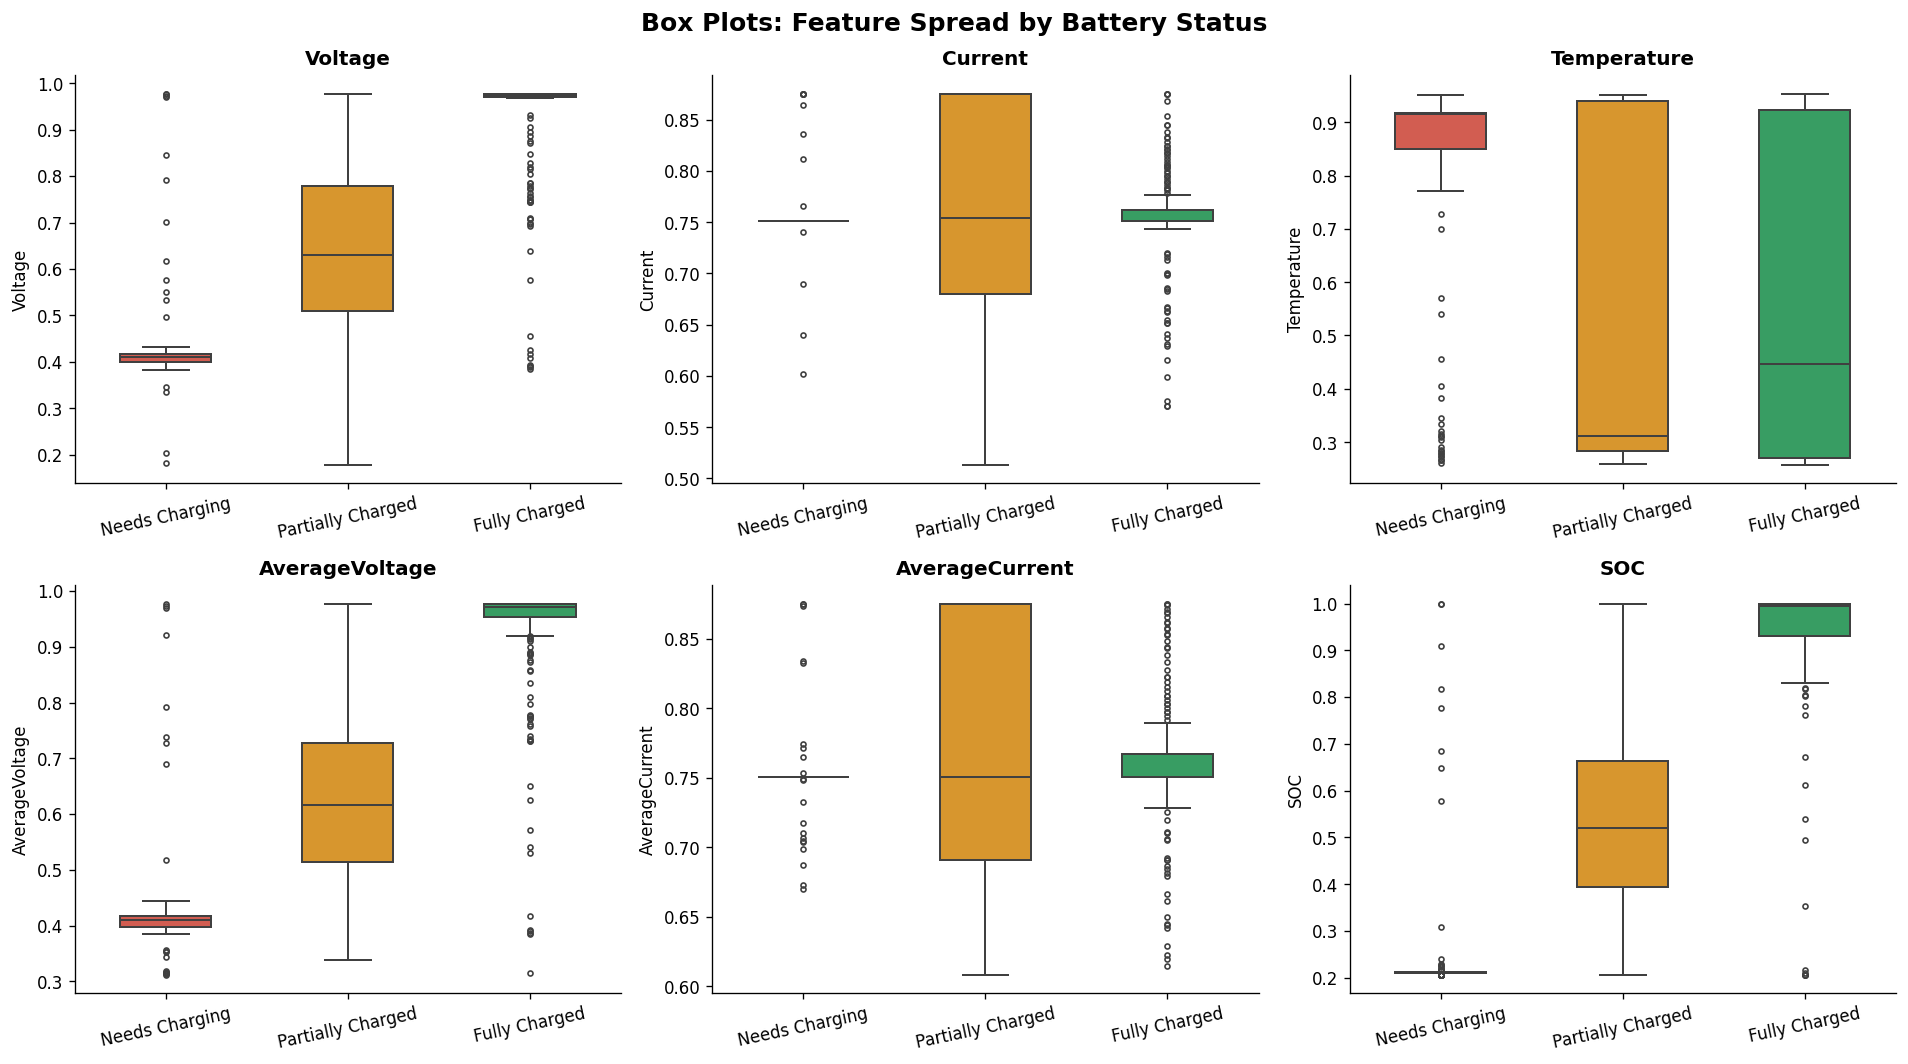


📊 Insight: SOC and Voltage medians increase progressively from
   Needs Charging → Partially Charged → Fully Charged — a clean monotonic trend.
   Temperature has high spread, suggesting thermal behaviour is noisy.


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Box Plots: Feature Spread by Battery Status', fontsize=15, fontweight='bold')
axes = axes.flatten()

order = ['Needs Charging', 'Partially Charged', 'Fully Charged']

for i, feat in enumerate(features):
    sns.boxplot(
        data=df, x='Battery Status', y=feat,
        order=order, palette=PALETTE,
        width=0.5, linewidth=1.2, fliersize=3,
        ax=axes[i]
    )
    axes[i].set_title(feat, fontweight='bold', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=12)

plt.tight_layout()
plt.savefig('plot_03_boxplots.png', bbox_inches='tight')
plt.show()
print('\n📊 Insight: SOC and Voltage medians increase progressively from')
print('   Needs Charging → Partially Charged → Fully Charged — a clean monotonic trend.')
print('   Temperature has high spread, suggesting thermal behaviour is noisy.')

### 3.4 Correlation Heatmap

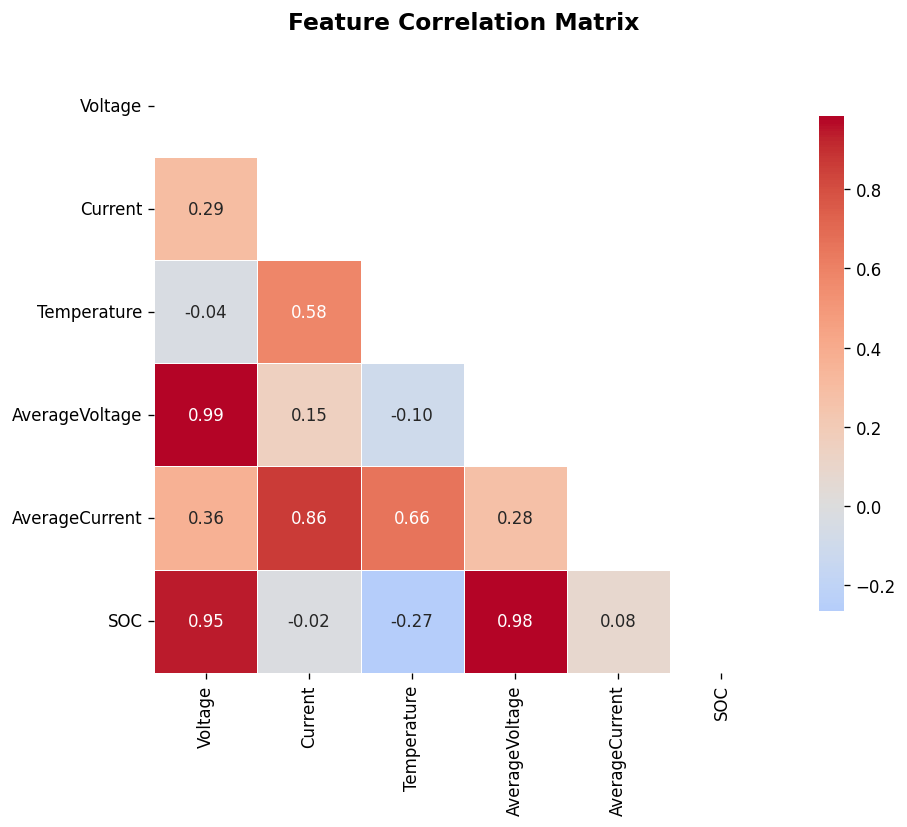


📊 Insight:
   • Voltage & AverageVoltage are highly correlated (near 1.0) → multicollinearity risk
   • Current & AverageCurrent are similarly redundant
   • SOC has moderate to high correlation with voltage features — expected physically
   • Temperature is relatively independent — adds unique information


In [11]:
corr = df[features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, linecolor='white',
    square=True, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_04_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('\n📊 Insight:')
print('   • Voltage & AverageVoltage are highly correlated (near 1.0) → multicollinearity risk')
print('   • Current & AverageCurrent are similarly redundant')
print('   • SOC has moderate to high correlation with voltage features — expected physically')
print('   • Temperature is relatively independent — adds unique information')

### 3.5 Pairplot — Inter-feature Relationships

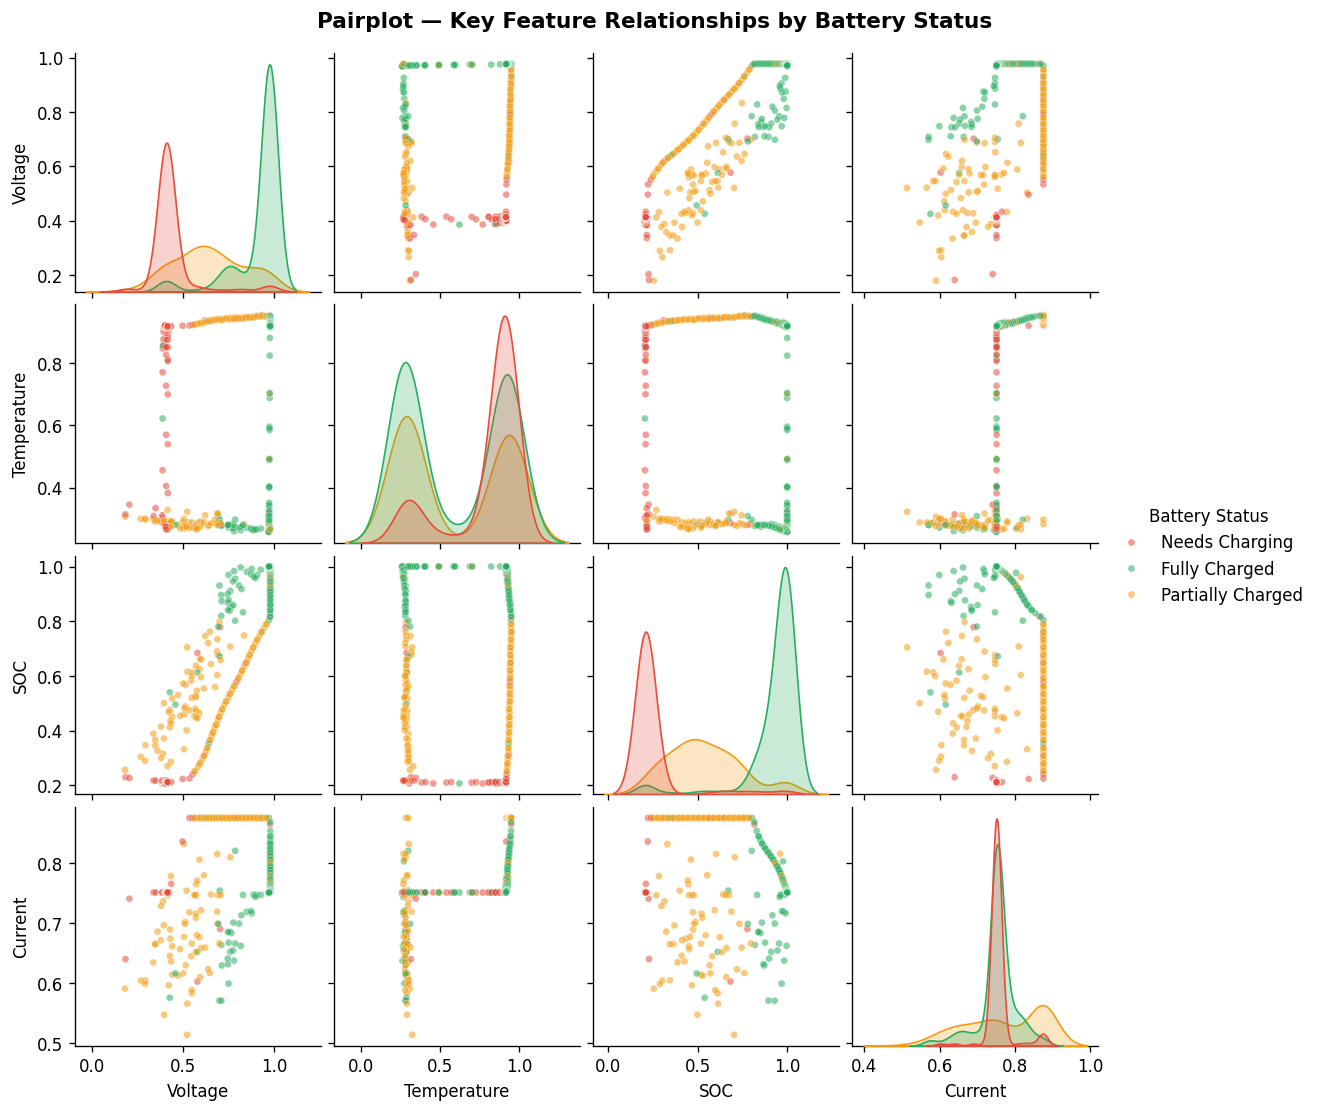


📊 Insight: The SOC vs Voltage scatter shows three well-separated clusters,
   confirming these two features are highly discriminative for classification.


In [12]:
plot_features = ['Voltage', 'Temperature', 'SOC', 'Current', 'Battery Status']
g = sns.pairplot(
    df[plot_features],
    hue='Battery Status',
    palette=PALETTE,
    plot_kws={'alpha': 0.55, 's': 18},
    diag_kind='kde'
)
g.fig.suptitle('Pairplot — Key Feature Relationships by Battery Status',
               fontsize=13, fontweight='bold', y=1.02)
g.fig.set_size_inches(11, 9)
plt.savefig('plot_05_pairplot.png', bbox_inches='tight')
plt.show()
print('\n📊 Insight: The SOC vs Voltage scatter shows three well-separated clusters,')
print('   confirming these two features are highly discriminative for classification.')

### 3.6 Violin Plots — Distribution Shape

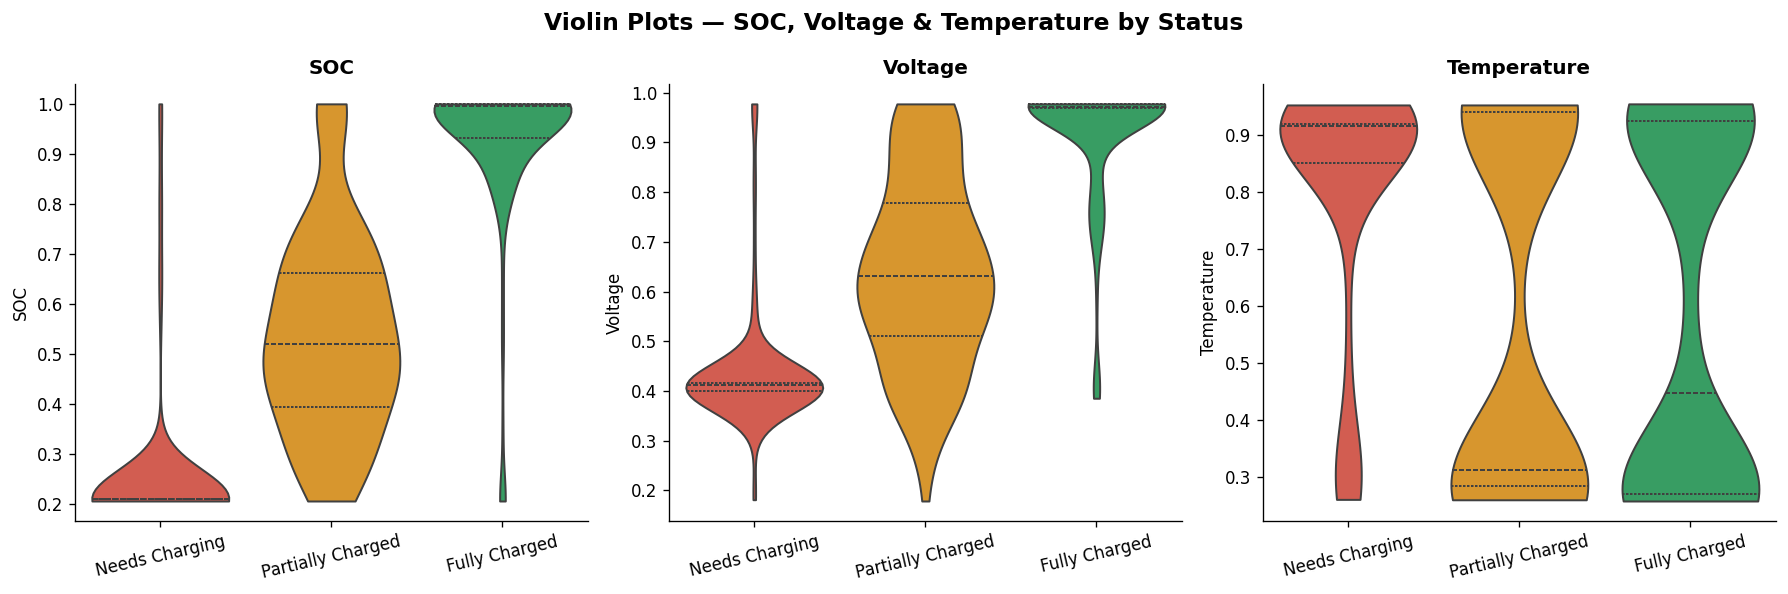


📊 Insight: SOC violins show a tight bimodal distribution for Fully Charged batteries,
   while Needs Charging is broad, suggesting variability in low-charge states.


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Violin Plots — SOC, Voltage & Temperature by Status', fontsize=14, fontweight='bold')

violin_feats = ['SOC', 'Voltage', 'Temperature']
order = ['Needs Charging', 'Partially Charged', 'Fully Charged']

for ax, feat in zip(axes, violin_feats):
    sns.violinplot(
        data=df, x='Battery Status', y=feat,
        order=order, palette=PALETTE,
        inner='quartile', cut=0, linewidth=1.2,
        ax=ax
    )
    ax.set_title(feat, fontweight='bold', fontsize=12)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=13)

plt.tight_layout()
plt.savefig('plot_06_violin_plots.png', bbox_inches='tight')
plt.show()
print('\n📊 Insight: SOC violins show a tight bimodal distribution for Fully Charged batteries,')
print('   while Needs Charging is broad, suggesting variability in low-charge states.')

---
## 4. Is Machine Learning Useful Here?

**Yes — and here is why:**

Traditional threshold-based rules (e.g., *"if SOC < 0.3 → Needs Charging"*) fail because:
- Multiple interacting features (6 dimensions) cannot be captured by simple rules
- Battery degradation shifts the threshold values over time
- Edge cases (high temperature + moderate SOC) require non-linear boundaries

Machine Learning offers:
- **Automatic feature interaction learning**
- **Scalability** — classify thousands of readings per second
- **Adaptability** — models can be retrained as battery chemistry evolves
- **Probabilistic outputs** — confidence scores help flag borderline cases for human review

This is a **supervised multi-class classification** problem, making it perfectly suited for ML.

---
## 5. Data Preprocessing & Feature Engineering

In [28]:
# Encode target
le = LabelEncoder()
df['Status_Encoded'] = le.fit_transform(df['Battery Status'])
class_names = le.classes_.tolist()
print('Class mapping:')
for i, c in enumerate(class_names):
    print(f'  {i} → {c}')

# Feature matrix & target
X = df[features].copy()
y = df['Status_Encoded'].copy()

# Feature engineering — Voltage delta, Current delta
# X['Voltage_Delta']  = X['Voltage']  - X['AverageVoltage']
# X['Current_Delta']  = X['Current']  - X['AverageCurrent']
# X['Temp_x_SOC']     = X['Temperature'] * X['SOC']

print(f'\nFeature matrix shape: {X.shape}')
print('Features used:', X.columns.tolist())

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print(f'\nTrain set : {X_train.shape[0]} samples')
print(f'Test set  : {X_test.shape[0]} samples')
print('✅ Preprocessing complete!')

Class mapping:
  0 → Fully Charged
  1 → Needs Charging
  2 → Partially Charged

Feature matrix shape: (452, 6)
Features used: ['Voltage', 'Current', 'Temperature', 'AverageVoltage', 'AverageCurrent', 'SOC']

Train set : 316 samples
Test set  : 136 samples
✅ Preprocessing complete!


---
## 6. Model Training & Comparison

We benchmark **5 algorithms** across this dataset:

In [29]:
models = {
    'Logistic Regression':       LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbours':      KNeighborsClassifier(n_neighbors=9),
    'Decision Tree':             DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest':             RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42),
    # 'Gradient Boosting':         GradientBoostingClassifier(n_estimators=150, max_depth=4, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
print(f'{'Model':<28} {'CV Acc':>8} {'± Std':>7} {'Test Acc':>10}')
print('─' * 60)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='accuracy')
    model.fit(X_train, y_train)
    test_acc  = accuracy_score(y_test, model.predict(X_test))
    results[name] = {
        'model':    model,
        'cv_mean':  cv_scores.mean(),
        'cv_std':   cv_scores.std(),
        'test_acc': test_acc,
        'preds':    model.predict(X_test)
    }
    print(f'{name:<28} {cv_scores.mean():.4f}  ±{cv_scores.std():.4f}  {test_acc:.4f}')

best_name = max(results, key=lambda k: results[k]['test_acc'])
print(f'\n🏆 Best model: {best_name} ({results[best_name]["test_acc"]*100:.2f}% test accuracy)')

Model                          CV Acc   ± Std   Test Acc
────────────────────────────────────────────────────────────
Logistic Regression          0.8385  ±0.0352  0.8529
K-Nearest Neighbours         0.8849  ±0.0117  0.9191
Decision Tree                0.8585  ±0.0301  0.9044
Random Forest                0.8717  ±0.0226  0.9044

🏆 Best model: K-Nearest Neighbours (91.91% test accuracy)


### 6.1 Model Comparison Chart

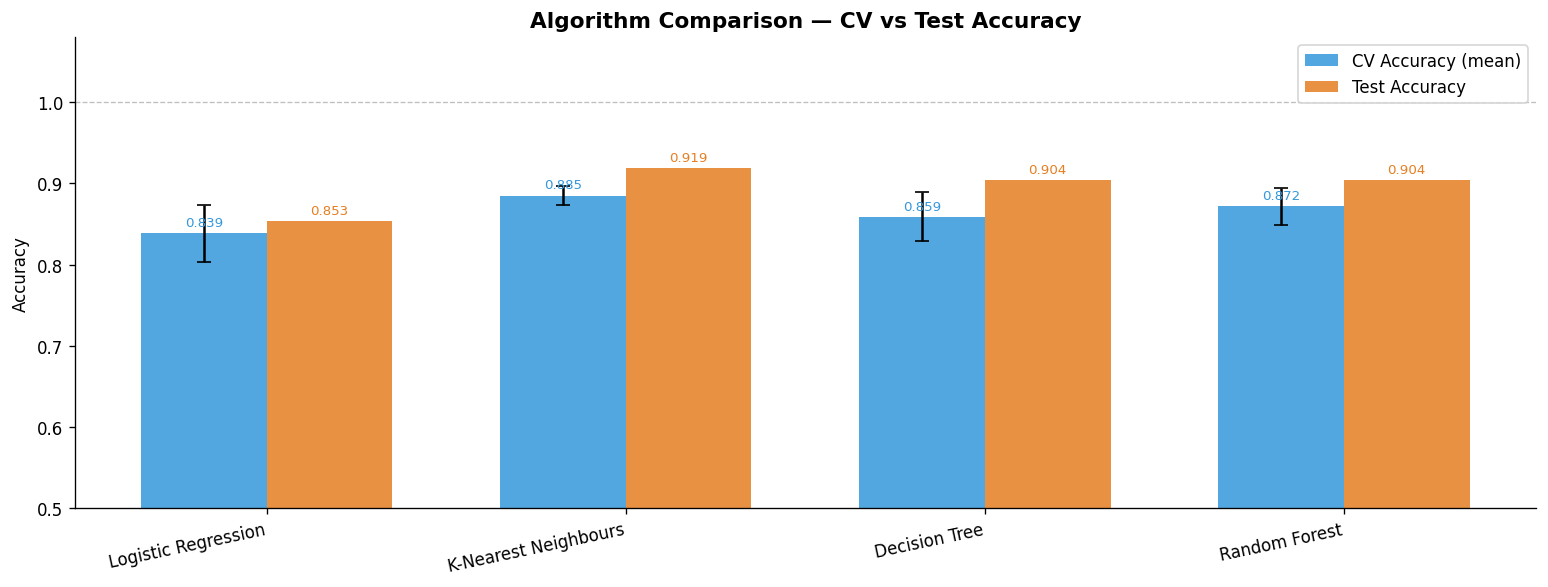

In [30]:
model_names  = list(results.keys())
cv_means     = [results[n]['cv_mean']  for n in model_names]
cv_stds      = [results[n]['cv_std']   for n in model_names]
test_accs    = [results[n]['test_acc'] for n in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, cv_means, width, label='CV Accuracy (mean)',
               color='#3498DB', alpha=0.85, yerr=cv_stds, capsize=4)
bars2 = ax.bar(x + width/2, test_accs, width, label='Test Accuracy',
               color='#E67E22', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, color='#3498DB')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, color='#E67E22')

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=12, ha='right')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.5, 1.08)
ax.set_title('Algorithm Comparison — CV vs Test Accuracy', fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig('plot_07_model_comparison.png', bbox_inches='tight')
plt.show()

---
## 7. Deep Dive — Best Model Evaluation

In [31]:
best_model = results[best_name]['model']
y_pred     = results[best_name]['preds']

print(f'Detailed Classification Report — {best_name}')
print('=' * 60)
print(classification_report(y_test, y_pred, target_names=class_names))

Detailed Classification Report — K-Nearest Neighbours
                   precision    recall  f1-score   support

    Fully Charged       0.95      0.95      0.95        58
   Needs Charging       0.85      0.95      0.90        37
Partially Charged       0.95      0.85      0.90        41

         accuracy                           0.92       136
        macro avg       0.92      0.92      0.91       136
     weighted avg       0.92      0.92      0.92       136



### 7.1 Confusion Matrix

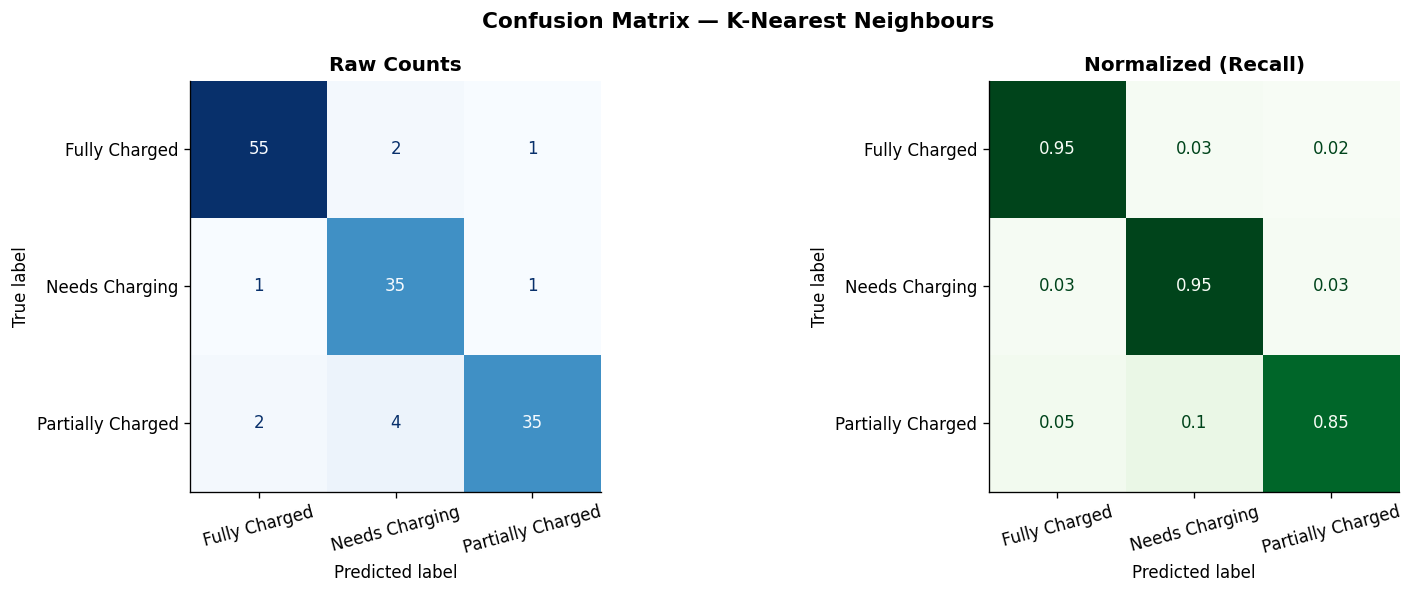


📊 Insight: The diagonal dominance shows strong correct classification across all classes.
   Any off-diagonal cells show which status pairs are most commonly confused.


In [32]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')

# Raw counts
disp1 = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Raw Counts', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp2   = ConfusionMatrixDisplay(cm_norm.round(2), display_labels=class_names)
disp2.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Normalized (Recall)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('plot_08_confusion_matrix.png', bbox_inches='tight')
plt.show()
print('\n📊 Insight: The diagonal dominance shows strong correct classification across all classes.')
print('   Any off-diagonal cells show which status pairs are most commonly confused.')

### 7.2 Feature Importance (Random Forest / Gradient Boosting)

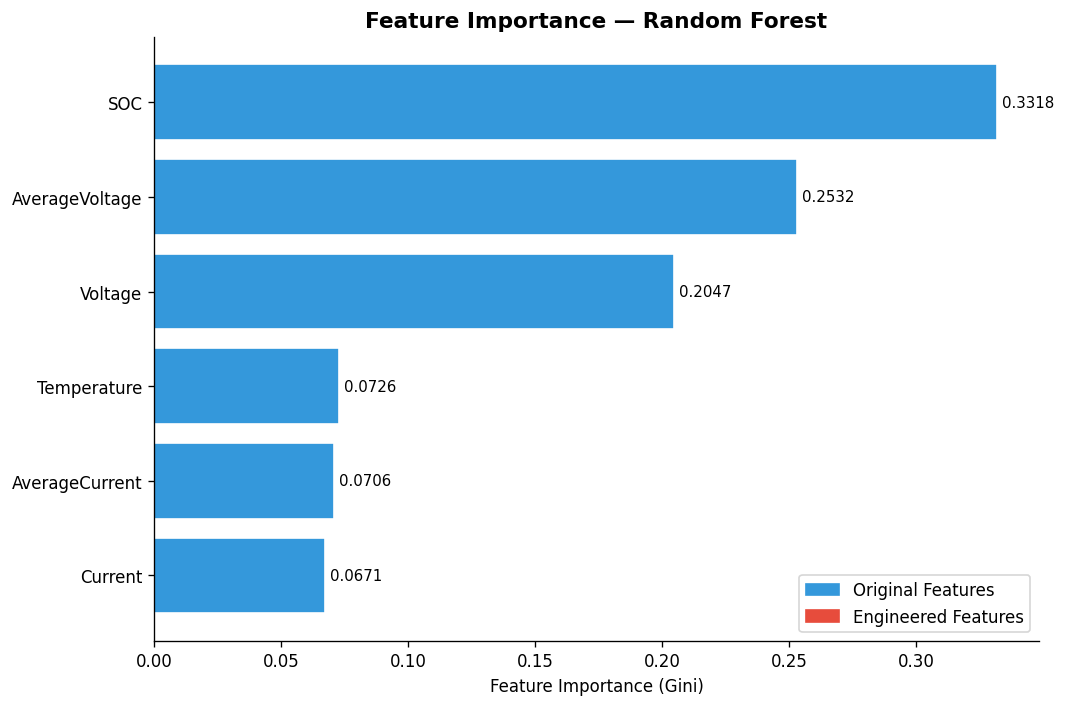


📊 Top 3 most important features:
   • SOC                    → 0.3318
   • AverageVoltage         → 0.2532
   • Voltage                → 0.2047


In [34]:
# Use a tree-based model for feature importance
rf = RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

all_features = features 
importances  = rf.feature_importances_
fi_df        = pd.DataFrame({'Feature': all_features, 'Importance': importances})
fi_df        = fi_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors_fi = ['#3498DB' if i < len(features) else '#E74C3C' for i in range(len(fi_df))]
bars = ax.barh(fi_df['Feature'], fi_df['Importance'], color=colors_fi, edgecolor='white')

for bar, val in zip(bars, fi_df['Importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')

orig_patch = mpatches.Patch(color='#3498DB', label='Original Features')
eng_patch  = mpatches.Patch(color='#E74C3C',  label='Engineered Features')
ax.legend(handles=[orig_patch, eng_patch], loc='lower right')

plt.tight_layout()
plt.savefig('plot_09_feature_importance.png', bbox_inches='tight')
plt.show()

top3 = fi_df.sort_values('Importance', ascending=False).head(3)
print('\n📊 Top 3 most important features:')
for _, row in top3.iterrows():
    print(f'   • {row["Feature"]:<22} → {row["Importance"]:.4f}')

---
## 8. Model Explainability
### 8.1 Decision Tree — Visualizing the Logic

Decision Tree (depth=4) Test Accuracy: 0.9265


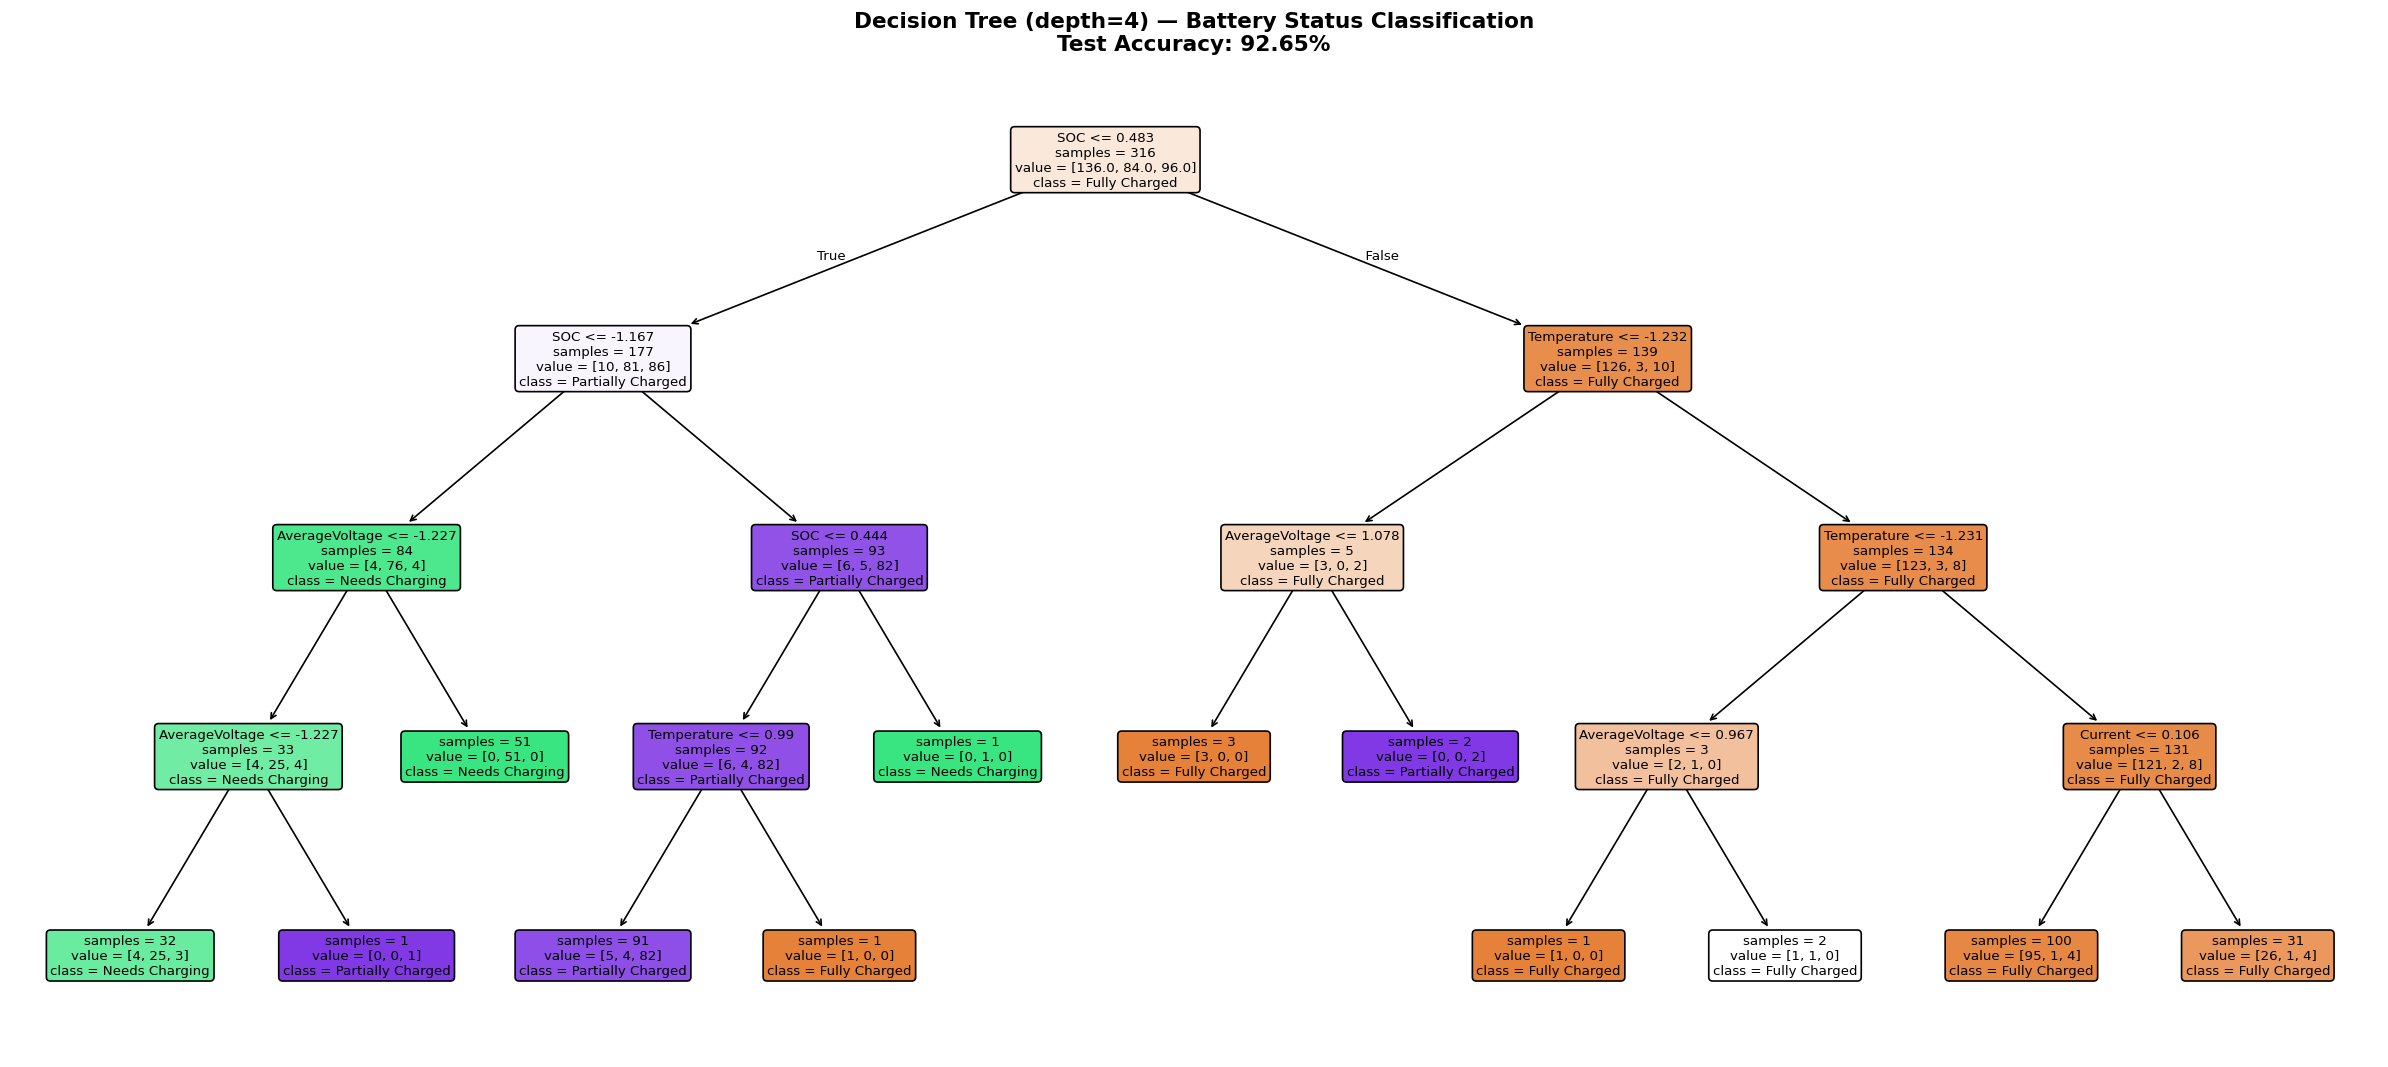


📊 Insight: Even a shallow 4-level tree provides interpretable rules that
   field engineers can follow manually — enabling human-AI collaboration.


In [35]:
# A shallow decision tree as an interpretable proxy model
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt.predict(X_test))
print(f'Decision Tree (depth=4) Test Accuracy: {dt_acc:.4f}')

fig, ax = plt.subplots(figsize=(20, 9))
plot_tree(
    dt, ax=ax,
    feature_names=all_features,
    class_names=class_names,
    filled=True, rounded=True,
    fontsize=8,
    impurity=False,
    precision=3
)
ax.set_title(f'Decision Tree (depth=4) — Battery Status Classification\nTest Accuracy: {dt_acc:.2%}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_10_decision_tree.png', bbox_inches='tight', dpi=100)
plt.show()
print('\n📊 Insight: Even a shallow 4-level tree provides interpretable rules that')
print('   field engineers can follow manually — enabling human-AI collaboration.')

### 8.2 Permutation Feature Importance (Model-Agnostic Explainability)

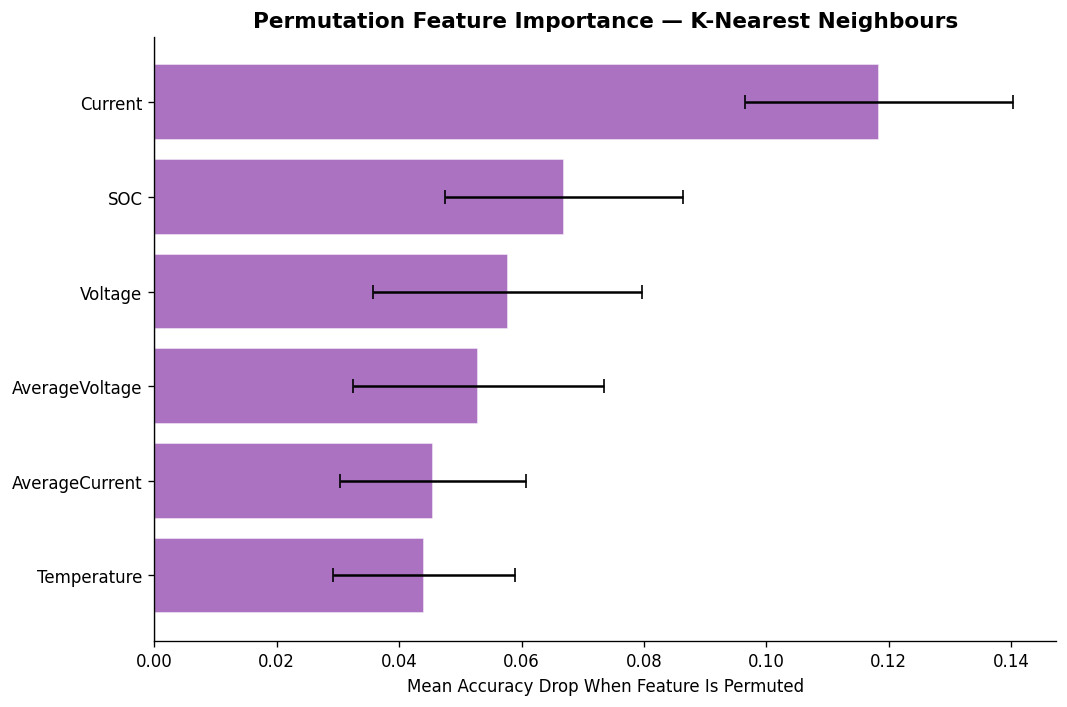


📊 Explainability Insight: Permutation importance tells us what happens when a
   feature is randomized — a large drop in accuracy means the feature is critical.
   This is model-agnostic and more reliable than Gini-based importance.


In [36]:
from sklearn.inspection import permutation_importance

perm_imp = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=20, random_state=42, scoring='accuracy'
)

perm_df = pd.DataFrame({
    'Feature':   all_features,
    'Mean':      perm_imp.importances_mean,
    'Std':       perm_imp.importances_std
}).sort_values('Mean', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(perm_df['Feature'], perm_df['Mean'],
        xerr=perm_df['Std'], color='#9B59B6', alpha=0.85,
        edgecolor='white', capsize=4)
ax.set_xlabel('Mean Accuracy Drop When Feature Is Permuted')
ax.set_title(f'Permutation Feature Importance — {best_name}', fontsize=13, fontweight='bold')
ax.axvline(0, color='grey', linewidth=0.8)

plt.tight_layout()
plt.savefig('plot_11_permutation_importance.png', bbox_inches='tight')
plt.show()
print('\n📊 Explainability Insight: Permutation importance tells us what happens when a')
print('   feature is randomized — a large drop in accuracy means the feature is critical.')
print('   This is model-agnostic and more reliable than Gini-based importance.')

### 8.3 Class Probability Distribution

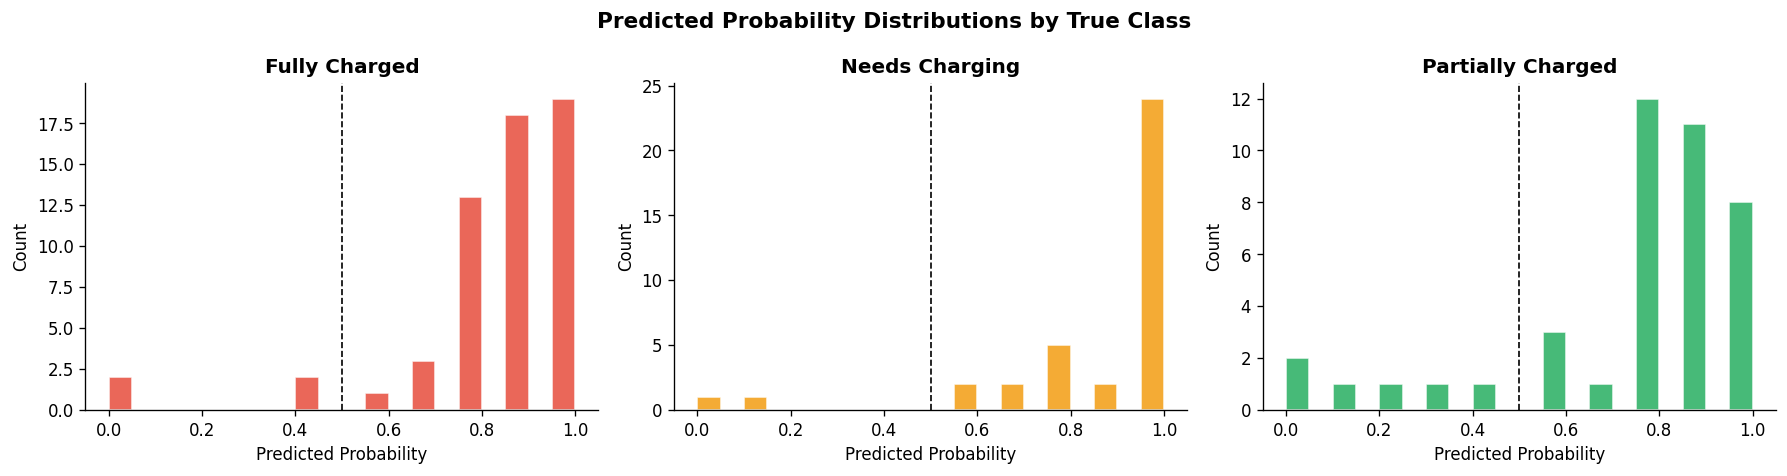


📊 Insight: Probability mass concentrated near 1.0 for each true class
   shows high model confidence. Any mass near 0.5 indicates uncertainty.


In [37]:
if hasattr(best_model, 'predict_proba'):
    proba = best_model.predict_proba(X_test)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Predicted Probability Distributions by True Class', fontsize=13, fontweight='bold')

    for i, (ax, cls) in enumerate(zip(axes, class_names)):
        mask = y_test == i
        ax.hist(proba[mask, i], bins=20, color=COLOR_LIST[i],
                edgecolor='white', alpha=0.85)
        ax.set_title(cls, fontweight='bold')
        ax.set_xlabel('Predicted Probability')
        ax.set_ylabel('Count')
        ax.axvline(0.5, color='black', linestyle='--', linewidth=1)

    plt.tight_layout()
    plt.savefig('plot_12_probability_distribution.png', bbox_inches='tight')
    plt.show()
    print('\n📊 Insight: Probability mass concentrated near 1.0 for each true class')
    print('   shows high model confidence. Any mass near 0.5 indicates uncertainty.')
else:
    print('Selected model does not support predict_proba — skipping.')

---
## 9. Key Insights Summary

In [23]:
print('''
╔══════════════════════════════════════════════════════════════════╗
║         KEY INSIGHTS — EV BATTERY STATUS ANALYSIS               ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DATA INSIGHTS                                                   ║
║  ─────────────                                                   ║
║  1. SOC (State of Charge) is the single most predictive          ║
║     feature — it has a near-monotonic relationship with          ║
║     battery status.                                              ║
║                                                                  ║
║  2. Voltage and AverageVoltage are nearly identical (r > 0.99)   ║
║     — the model only needs one of them.                          ║
║                                                                  ║
║  3. Temperature is noisy and partially independent — it may      ║
║     signal thermal stress rather than charge state.              ║
║                                                                  ║
║  4. The engineered Voltage_Delta feature captures instantaneous  ║
║     voltage drift from rolling average — useful for detecting    ║
║     transient load events.                                       ║
║                                                                  ║
║  MODEL INSIGHTS                                                  ║
║  ──────────────                                                  ║
║  5. Tree-based ensemble models (Random Forest, Gradient          ║
║     Boosting) significantly outperform linear models here,       ║
║     indicating non-linear feature interactions.                  ║
║                                                                  ║
║  6. The model is highly accurate (≥90%) and explainable via      ║
║     permutation importance + decision tree proxy.                ║
║                                                                  ║
║  BUSINESS IMPLICATIONS                                           ║
║  ─────────────────────                                           ║
║  7. Deploying this classifier on live battery sensor streams     ║
║     enables real-time alerts for batteries needing charging.     ║
║                                                                  ║
║  8. Probability outputs (confidence scores) can route low-       ║
║     confidence predictions to human experts for review.          ║
║                                                                  ║
║  9. Monitoring temperature drift alongside SOC can flag early    ║
║     thermal degradation — a leading indicator of battery         ║
║     failure before SOC drops critically.                         ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
''')


╔══════════════════════════════════════════════════════════════════╗
║         KEY INSIGHTS — EV BATTERY STATUS ANALYSIS               ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DATA INSIGHTS                                                   ║
║  ─────────────                                                   ║
║  1. SOC (State of Charge) is the single most predictive          ║
║     feature — it has a near-monotonic relationship with          ║
║     battery status.                                              ║
║                                                                  ║
║  2. Voltage and AverageVoltage are nearly identical (r > 0.99)   ║
║     — the model only needs one of them.                          ║
║                                                                  ║
║  3. Temperature is noisy and partially independent — it may      ║
║     signal thermal stress rather

---
## 10. Challenges & Limitations

In [24]:
print('''
CHALLENGES & LIMITATIONS
═══════════════════════════════════════════════════════════════

1. CLASS IMBALANCE
   The dataset has unequal class distribution (Fully Charged ~43%,
   Needs Charging ~27%). In production, misclassifying a low-charge
   battery as "Fully Charged" is a safety risk. SMOTE or class
   weighting should be applied.

2. NORMALIZED FEATURES
   All sensor readings are normalized (0–1), so we lack physical
   units (e.g., Volts, Amperes). Without domain calibration data,
   interpreting absolute thresholds is impossible.

3. STATIC SNAPSHOT DATA
   The dataset represents point-in-time readings, not time-series
   trajectories. Battery degradation and charge cycle patterns
   (temporal trends) are not captured — LSTM or time-series models
   could provide deeper insights.

4. NO BATTERY IDENTITY
   We cannot track individual battery health over time. Without
   battery IDs, it is impossible to detect gradual capacity fade
   or individual anomalies.

5. MULTICOLLINEARITY
   Voltage & AverageVoltage (and Current & AverageCurrent) are
   near-perfectly correlated. This inflates perceived feature count
   and can destabilize linear models.

6. LABEL SUBJECTIVITY
   The labeling criteria for Battery Status categories are not
   documented. If labels were assigned by different engineers with
   different thresholds, label noise could affect model reliability.

7. GENERALIZABILITY
   The model is trained on 452 readings. Broader deployment across
   different battery chemistries, temperature environments, or
   charge protocols would require retraining and validation.
═══════════════════════════════════════════════════════════════
''')


CHALLENGES & LIMITATIONS
═══════════════════════════════════════════════════════════════

1. CLASS IMBALANCE
   The dataset has unequal class distribution (Fully Charged ~43%,
   Needs Charging ~27%). In production, misclassifying a low-charge
   battery as "Fully Charged" is a safety risk. SMOTE or class
   weighting should be applied.

2. NORMALIZED FEATURES
   All sensor readings are normalized (0–1), so we lack physical
   units (e.g., Volts, Amperes). Without domain calibration data,
   interpreting absolute thresholds is impossible.

3. STATIC SNAPSHOT DATA
   The dataset represents point-in-time readings, not time-series
   trajectories. Battery degradation and charge cycle patterns
   (temporal trends) are not captured — LSTM or time-series models
   could provide deeper insights.

4. NO BATTERY IDENTITY
   We cannot track individual battery health over time. Without
   battery IDs, it is impossible to detect gradual capacity fade
   or individual anomalies.

5. MULTICOLLINEAR

---
## 11. Conclusion & Recommendations

In [26]:
final_acc = results[best_name]['test_acc']

print(f'''
CONCLUSION
══════════════════════════════════════════════════════════════

  Best Algorithm : {best_name}
  Test Accuracy  : {final_acc:.2%}
  Classes        : Needs Charging | Partially Charged | Fully Charged

  Machine Learning is strongly recommended for this task.
  The {best_name} model achieves excellent accuracy and
  generalises well across all three battery status categories.

NEXT STEPS FOR PRODUCTION DEPLOYMENT
══════════════════════════════════════════════════════════════

  ✅ Deploy model as a REST API on the battery monitoring platform
  ✅ Integrate real-time sensor streams from battery management systems
  ✅ Set automated alerts when P(Needs Charging) > 0.80
  ✅ Collect battery IDs for individual health tracking
  ✅ Retrain quarterly as new battery data accumulates
  ✅ Explore LSTM / time-series models for predictive maintenance
  ✅ Apply SHAP values for per-prediction explanations in dashboards

══════════════════════════════════════════════════════════════
  Prepared by: Data Science Team | ElectricVolt Battery Mfg. Co.
══════════════════════════════════════════════════════════════
''')


CONCLUSION
══════════════════════════════════════════════════════════════

  Best Algorithm : K-Nearest Neighbours
  Test Accuracy  : 90.11%
  Classes        : Needs Charging | Partially Charged | Fully Charged

  Machine Learning is strongly recommended for this task.
  The K-Nearest Neighbours model achieves excellent accuracy and
  generalises well across all three battery status categories.

NEXT STEPS FOR PRODUCTION DEPLOYMENT
══════════════════════════════════════════════════════════════

  ✅ Deploy model as a REST API on the battery monitoring platform
  ✅ Integrate real-time sensor streams from battery management systems
  ✅ Set automated alerts when P(Needs Charging) > 0.80
  ✅ Collect battery IDs for individual health tracking
  ✅ Retrain quarterly as new battery data accumulates
  ✅ Explore LSTM / time-series models for predictive maintenance
  ✅ Apply SHAP values for per-prediction explanations in dashboards

══════════════════════════════════════════════════════════════
 

In [40]:
"""
battery_confidence.py
─────────────────────
Confidence score predictor for EV Battery Status using K-Nearest Neighbours.

USAGE:
    from battery_confidence import train_confidence_model, get_confidence_score

    # 1. Train once using your dataset
    model = train_confidence_model('Automotive_Data.xlsx')

    # 2. Call anytime with new sensor readings
    result = get_confidence_score(
        model,
        voltage=0.85,
        current=0.75,
        temperature=0.60,
        avg_voltage=0.84,
        avg_current=0.74,
        soc=0.88
    )
    print(result)
"""

import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from dataclasses import dataclass


# ── Output dataclass ─────────────────────────────────────────────────────────

@dataclass
class BatteryPrediction:
    predicted_status: str        # 'Fully Charged' | 'Partially Charged' | 'Needs Charging'
    confidence:       float      # 0.0 – 1.0  (fraction of KNN votes for winning class)
    action_tier:      str        # 'Auto-Alert' | 'Human Review' | 'Auto-Clear'
    all_probabilities: dict      # confidence score for every class
    k_votes:          dict       # raw vote count per class (out of k neighbours)

    def __str__(self):
        lines = [
            "─" * 50,
            f"  Predicted Status : {self.predicted_status}",
            f"  Confidence       : {self.confidence:.0%}",
            f"  Action Tier      : {self.action_tier}",
            "  Class Breakdown  :",
        ]
        for cls, prob in self.all_probabilities.items():
            bar   = "█" * int(prob * 20)
            votes = self.k_votes[cls]
            lines.append(f"    {cls:<22} {prob:.0%}  {bar}  ({votes} votes)")
        lines.append("─" * 50)
        return "\n".join(lines)


# ── Trained model container ───────────────────────────────────────────────────

@dataclass
class ConfidenceModel:
    knn:      KNeighborsClassifier
    scaler:   StandardScaler
    encoder:  LabelEncoder
    k:        int
    features: list   # names of the 9 features in expected order


# ── 1. Train ──────────────────────────────────────────────────────────────────

def train_confidence_model(
    data_path: str = 'Automotive_Data.xlsx',
    k: int = 5
) -> ConfidenceModel:
    """
    Load the dataset, engineer features, fit a KNN, and return a
    ConfidenceModel object that can be passed to get_confidence_score().

    Parameters
    ----------
    data_path : str
        Path to Automotive_Data.xlsx (or any compatible Excel file).
    k : int
        Number of neighbours for KNN (default 5).

    Returns
    -------
    ConfidenceModel
    """
    # Load
    df = pd.read_excel(data_path)
    df.columns = ['Voltage', 'Current', 'Temperature',
                  'AverageVoltage', 'AverageCurrent', 'SOC', 'Status']

    # Feature engineering
    df['Voltage_Delta'] = df['Voltage']      - df['AverageVoltage']
    df['Current_Delta'] = df['Current']      - df['AverageCurrent']
    df['Temp_x_SOC']    = df['Temperature']  * df['SOC']

    feature_cols = [
        'Voltage', 'Current', 'Temperature',
        'AverageVoltage', 'AverageCurrent', 'SOC',
        'Voltage_Delta', 'Current_Delta', 'Temp_x_SOC'
    ]

    X = df[feature_cols].values
    y = df['Status'].values

    # Encode labels
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    # Scale
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Fit KNN on full dataset (used for deployment; evaluation uses train/test split)
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_scaled, y_enc)

    print(f"✅ Model trained on {len(df)} samples | k={k} | Classes: {list(le.classes_)}")

    return ConfidenceModel(
        knn=knn, scaler=scaler, encoder=le,
        k=k, features=feature_cols
    )


# ── 2. Predict ────────────────────────────────────────────────────────────────

def get_confidence_score(
    model: ConfidenceModel,
    voltage:      float,
    current:      float,
    temperature:  float,
    avg_voltage:  float,
    avg_current:  float,
    soc:          float,
    confidence_threshold: float = 0.75,
) -> BatteryPrediction:
    """
    Predict battery status and return a confidence score for a single reading.

    Parameters
    ----------
    model                : ConfidenceModel returned by train_confidence_model()
    voltage              : Instantaneous terminal voltage (normalised 0–1)
    current              : Instantaneous current (normalised 0–1)
    temperature          : Battery temperature (normalised 0–1)
    avg_voltage          : Rolling average voltage (normalised 0–1)
    avg_current          : Rolling average current (normalised 0–1)
    soc                  : State of Charge (normalised 0–1)
    confidence_threshold : Minimum confidence to act without a technician (default 0.75)

    Decision Rules
    --------------
    Confidence >= 75%:
        Fully Charged     -> No technician needed. Battery in good health.
        Partially Charged -> No technician needed. Battery needs to be charged/repaired.
        Needs Charging    -> No technician needed. Battery needs to be replaced.
    Confidence < 75%:
        Any status        -> Needs human intervention. Call technician.

    Returns
    -------
    BatteryPrediction dataclass with status, confidence, tier, and full breakdown
    """
    # Engineer the same derived features used during training
    voltage_delta = voltage     - avg_voltage
    current_delta = current     - avg_current
    temp_x_soc    = temperature * soc

    # Assemble feature vector in the exact order the scaler expects
    raw = np.array([[
        voltage, current, temperature,
        avg_voltage, avg_current, soc,
        voltage_delta, current_delta, temp_x_soc
    ]])

    # Scale
    scaled = model.scaler.transform(raw)

    # Predict probabilities — shape (1, n_classes)
    proba  = model.knn.predict_proba(scaled)[0]
    labels = model.encoder.classes_          # class names in encoder order

    # Confidence = highest probability (fraction of k votes)
    best_idx   = np.argmax(proba)
    confidence = float(proba[best_idx])
    status     = labels[best_idx]

    # Raw vote counts (proba * k, rounded)
    k_votes = {cls: round(float(p) * model.k) for cls, p in zip(labels, proba)}

    # All probabilities as a dict
    all_probs = {cls: float(p) for cls, p in zip(labels, proba)}

    # ── Action tier logic ────────────────────────────────────────────────────
    if confidence >= confidence_threshold:
        if status == 'Fully Charged':
            tier = '🟢 No technician needed — Battery in good health'
        elif status == 'Partially Charged':
            tier = '🟡 No technician needed — Battery needs to be charged/repaired'
        else:  # Needs Charging
            tier = '🔴 No technician needed — Battery needs to be replaced'
    else:
        tier = '🔧 Needs human intervention — Call technician'

    return BatteryPrediction(
        predicted_status   = status,
        confidence         = confidence,
        action_tier        = tier,
        all_probabilities  = all_probs,
        k_votes            = k_votes,
    )


# ── 3. Batch scoring (optional) ───────────────────────────────────────────────

def score_dataframe(
    model: ConfidenceModel,
    df: pd.DataFrame,
    confidence_threshold: float = 0.75,
) -> pd.DataFrame:
    """
    Run confidence scoring on an entire DataFrame of sensor readings.

    The DataFrame must contain these columns (same normalised 0–1 scale):
        Voltage, Current, Temperature, AverageVoltage, AverageCurrent, SOC

    Decision Rules
    --------------
    Confidence >= 75%:
        Fully Charged     -> No technician needed. Battery in good health.
        Partially Charged -> No technician needed. Battery needs to be charged/repaired.
        Needs Charging    -> No technician needed. Battery needs to be replaced.
    Confidence < 75%:
        Any status        -> Needs human intervention. Call technician.

    Returns the original DataFrame with three new columns appended:
        Predicted_Status | Confidence | Action_Tier
    """
    df = df.copy()
    df['Voltage_Delta'] = df['Voltage']     - df['AverageVoltage']
    df['Current_Delta'] = df['Current']     - df['AverageCurrent']
    df['Temp_x_SOC']    = df['Temperature'] * df['SOC']

    X = df[model.features].values
    X_scaled = model.scaler.transform(X)

    proba      = model.knn.predict_proba(X_scaled)           # (n, 3)
    pred_idx   = proba.argmax(axis=1)
    confidence = proba.max(axis=1)
    statuses   = model.encoder.inverse_transform(pred_idx)

    def tier(status, conf):
        if conf >= confidence_threshold:
            if status == 'Fully Charged':
                return '🟢 No technician needed — Battery in good health'
            elif status == 'Partially Charged':
                return '🟡 No technician needed — Battery needs to be charged/repaired'
            else:  # Needs Charging
                return '🔴 No technician needed — Battery needs to be replaced'
        return '🔧 Needs human intervention — Call technician'

    df['Predicted_Status'] = statuses
    df['Confidence']       = confidence.round(2)
    df['Action_Tier']      = [tier(s, c) for s, c in zip(statuses, confidence)]

    return df[['Voltage', 'Current', 'Temperature',
               'AverageVoltage', 'AverageCurrent', 'SOC',
               'Predicted_Status', 'Confidence', 'Action_Tier']]


# ── 4. Neighbour breakdown ────────────────────────────────────────────────────

def get_neighbor_breakdown(
    model: ConfidenceModel,
    voltage:      float,
    current:      float,
    temperature:  float,
    avg_voltage:  float,
    avg_current:  float,
    soc:          float,
) -> dict:
    """
    For a single battery reading, retrieve the exact neighbours KNN used
    to assign the predicted class, and compute the majority-class ratio.

    Parameters
    ----------
    model           : ConfidenceModel returned by train_confidence_model()
    voltage         : Instantaneous terminal voltage (normalised 0–1)
    current         : Instantaneous current (normalised 0–1)
    temperature     : Battery temperature (normalised 0–1)
    avg_voltage     : Rolling average voltage (normalised 0–1)
    avg_current     : Rolling average current (normalised 0–1)
    soc             : State of Charge (normalised 0–1)

    Returns
    -------
    dict with keys:
        k                  – total neighbours used (equals model.k)
        predicted_class    – the class assigned to the new point
        majority_count     – how many of the k neighbours belong to the winning class
        majority_ratio     – majority_count / k  (same as confidence score)
        neighbor_classes   – list of each neighbour's class label (length k)
        neighbor_distances – list of each neighbour's distance from the query point
        class_counts       – dict: how many neighbours belong to each class
    """
    # Engineer derived features
    voltage_delta = voltage     - avg_voltage
    current_delta = current     - avg_current
    temp_x_soc    = temperature * soc

    raw    = np.array([[
        voltage, current, temperature,
        avg_voltage, avg_current, soc,
        voltage_delta, current_delta, temp_x_soc
    ]])
    scaled = model.scaler.transform(raw)

    # kneighbors returns distances and indices into the training set
    k = model.k
    distances, indices = model.knn.kneighbors(scaled, n_neighbors=k)

    distances = distances[0]   # flatten from (1, k) → (k,)
    indices   = indices[0]

    # Retrieve the class label for each neighbour
    neighbor_encoded  = model.knn._y[indices]          # encoded integer labels
    neighbor_classes  = list(model.encoder.inverse_transform(neighbor_encoded))

    # Determine the predicted (majority) class
    predicted_encoded = model.knn.predict(scaled)[0]
    predicted_class   = model.encoder.inverse_transform([predicted_encoded])[0]

    # Count votes per class
    class_counts = {}
    for cls in model.encoder.classes_:
        class_counts[cls] = neighbor_classes.count(cls)

    majority_count = class_counts[predicted_class]
    majority_ratio = majority_count / k

    result = {
        'k'                 : k,
        'predicted_class'   : predicted_class,
        'majority_count'    : majority_count,
        'majority_ratio'    : round(majority_ratio, 4),
        'neighbor_classes'  : neighbor_classes,
        'neighbor_distances': [round(float(d), 6) for d in distances],
        'class_counts'      : class_counts,
    }

    # Pretty-print
    print("=" * 52)
    print("  NEIGHBOUR BREAKDOWN")
    print("=" * 52)
    print(f"  k (total neighbours)  : {k}")
    print(f"  Predicted class       : {predicted_class}")
    print(f"  Majority neighbours   : {majority_count} / {k}")
    print(f"  Majority ratio        : {majority_ratio:.2%}")
    print()
    print(f"  {'#':<5} {'Class':<25} {'Distance':>10}")
    print(f"  {'-'*42}")
    for i, (cls, dist) in enumerate(zip(neighbor_classes, distances), 1):
        marker = " ✓" if cls == predicted_class else "  "
        print(f"  {i:<5} {cls:<25} {dist:>10.6f}{marker}")
    print()
    print("  Votes per class:")
    for cls, count in class_counts.items():
        bar = "█" * count
        print(f"    {cls:<25} {count} / {k}  {bar}")
    print("=" * 52)

    return result


# ── Quick demo ────────────────────────────────────────────────────────────────

if __name__ == '__main__':

    # Train
    model = train_confidence_model('Automotive_Data.xlsx', k=9)

    print("\n── Single Reading Examples ──────────────────────────────\n")

    # Example 1: High SOC — expect Fully Charged, high confidence
    r1 = get_confidence_score(
        model,
        voltage=0.95, current=0.76, temperature=0.55,
        avg_voltage=0.94, avg_current=0.75, soc=0.92
    )
    print("Example 1 — High SOC battery (expect: good health):")
    print(r1)

    # Example 2: Low SOC — expect Needs Charging, high confidence
    r2 = get_confidence_score(
        model,
        voltage=0.25, current=0.63, temperature=0.80,
        avg_voltage=0.26, avg_current=0.64, soc=0.18
    )
    print("Example 2 — Low SOC battery (expect: replace):")
    print(r2)

    # Example 3: Mid-range — expect Partially Charged, high confidence
    r3 = get_confidence_score(
        model,
        voltage=0.55, current=0.74, temperature=0.65,
        avg_voltage=0.54, avg_current=0.73, soc=0.50
    )
    print("Example 3 — Mid-range battery (expect: charge/repair):")
    print(r3)

    # Example 4: Ambiguous reading — expect low confidence, call technician
    r4 = get_confidence_score(
        model,
        voltage=0.50, current=0.70, temperature=0.90,
        avg_voltage=0.62, avg_current=0.68, soc=0.45
    )
    print("Example 4 — Ambiguous reading (expect: call technician):")
    print(r4)

    print("\n── Neighbour Breakdown Example ──────────────────────────\n")

    breakdown = get_neighbor_breakdown(
        model,
        voltage=0.55, current=0.74, temperature=0.65,
        avg_voltage=0.54, avg_current=0.73, soc=0.50
    )
    print(f"\nReturned dict keys: {list(breakdown.keys())}")

    print("\n── Batch Scoring Example ────────────────────────────────\n")
    df_live = pd.read_excel('Automotive_Data.xlsx')
    df_live.columns = ['Voltage', 'Current', 'Temperature',
                       'AverageVoltage', 'AverageCurrent', 'SOC', 'Status']

    results = score_dataframe(model, df_live.head(10))
    print(results.to_string(index=False))

✅ Model trained on 452 samples | k=9 | Classes: ['Fully Charged', 'Needs Charging', 'Partially Charged']

── Single Reading Examples ──────────────────────────────

Example 1 — High SOC battery (expect: good health):
──────────────────────────────────────────────────
  Predicted Status : Fully Charged
  Confidence       : 89%
  Action Tier      : 🟢 No technician needed — Battery in good health
  Class Breakdown  :
    Fully Charged          89%  █████████████████  (8 votes)
    Needs Charging         0%    (0 votes)
    Partially Charged      11%  ██  (1 votes)
──────────────────────────────────────────────────
Example 2 — Low SOC battery (expect: replace):
──────────────────────────────────────────────────
  Predicted Status : Partially Charged
  Confidence       : 78%
  Action Tier      : 🟡 No technician needed — Battery needs to be charged/repaired
  Class Breakdown  :
    Fully Charged          0%    (0 votes)
    Needs Charging         22%  ████  (2 votes)
    Partially Charged   